In [1]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import copy

from abm.rho_lookup_table import RhoLookupTable
from abm.endothelial_cell import EndothelialCell
from abm.stress_fibre import StressFibre
from abm.flow_field import FlowField
from src.config import load_abm_sim_cfg, load_bm_sweep_cfg
from src.paths import BM_RESULTS_DIR

from abm.scripts.run_abm_sim import run_abm_sim, run_abm_sim_single, get_perb_cfg, plot_cell

sim_cfg = load_abm_sim_cfg()
lut = RhoLookupTable(sim_cfg, BM_RESULTS_DIR)
perbs = sim_cfg['perturbations']


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.395 RhoC=0.406


In [2]:
dsp_cfg = get_perb_cfg(sim_cfg, perbs['DSP_KO'])
tjp1_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_KO'])
jcad_cfg = get_perb_cfg(sim_cfg, perbs['JCAD_KO'])
tjp1_jcad_cfg = get_perb_cfg(sim_cfg, perbs['TJP1_JCAD_DKO'])
dsp_jcad_cfg = get_perb_cfg(sim_cfg, perbs['DSP_JCAD_DKO'])

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 40.773376084921864, 'rest_length': 26.29068276024797, 'tension': 3.8440549107725865, 'activation': 0.3791800421293405}


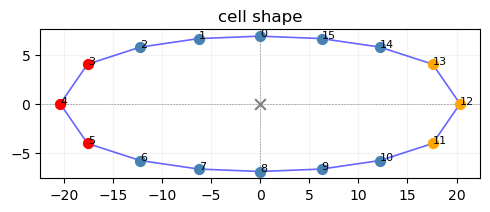

In [3]:
res_wt = run_abm_sim_single(sim_cfg, lut, 3000, 'WT', True)

In [4]:
res_wt['cell_final'], res_wt['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.449),
  'orientation': np.float64(-180.0),
  'area_ratio': np.float64(1.009),
  'mean_rhoa_pole': 0.542,
  'mean_rhoa_lat': 0.538,
  'mean_rhoa': 0.54,
  'mean_rhoc': 0.58,
  'a_sf': 0.379,
  'sf_tension': np.float64(3.844),
  'k_active_pole': np.float64(3.704),
  'k_active_flank': np.float64(3.694),
  'tensile_pole': 18.965,
  'f_total': 10.0},
     id   side  extension  stiffness  tension  alignment
 0    0  flank     1.1663     3.6967   4.3133      0.999
 1    1  flank     1.1476     3.6909   4.2397      0.990
 2    2  polar     1.1027     3.7037   4.0909      0.951
 3    3  polar     0.6151     3.7053   2.2844      0.565
 4    4  polar     0.6151     3.7053   2.2844      0.565
 5    5  polar     1.1027     3.7037   4.0909      0.951
 6    6  flank     1.1476     3.6909   4.2397      0.990
 7    7  flank     1.1663     3.6967   4.3133      0.999
 8    8  flank     1.1663     3.6967   4.3133      0.999
 9    9  flank     1.1476     3.6909   4.2397

In [ ]:
res_jcad = run_abm_sim_single(jcad_cfg, lut, 3000, 'JCAD', True)

In [ ]:
res_jcad['cell_final'], res_jcad['springs_final']

In [ ]:
res_dsp = run_abm_sim_single(dsp_cfg, lut, 2000, 'DSP', True)

In [ ]:
res_dsp['cell_final'], res_dsp['springs_final']

In [ ]:
res_dsp_jcad = run_abm_sim_single(dsp_jcad_cfg, lut, 2000, 'DSP_JCAD', True)

In [ ]:
res_dsp_jcad['cell_final'], res_dsp_jcad['springs_final']

>>> INFO: Initiated flow field with magnitude 10.0 and unit direction [1. 0.]
{'length': 38.537894928934676, 'rest_length': 26.29068276024797, 'tension': 0.29663676357365815, 'activation': 0.03460117602769833}


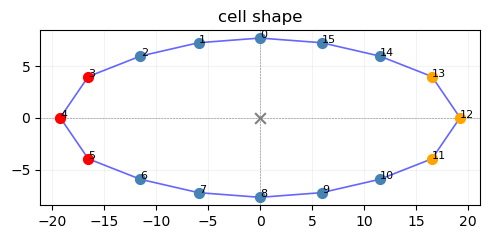

In [5]:
res_tjp1 = run_abm_sim_single(tjp1_cfg, lut, 3000, 'TJP1', True)

In [6]:
res_tjp1['cell_final'], res_tjp1['springs_final']

({'cell_id': 0,
  'ar': np.float64(2.176),
  'orientation': np.float64(-180.0),
  'area_ratio': np.float64(1.0084),
  'mean_rhoa_pole': 0.687,
  'mean_rhoa_lat': 0.703,
  'mean_rhoa': 0.697,
  'mean_rhoc': 0.235,
  'a_sf': 0.035,
  'sf_tension': np.float64(0.297),
  'k_active_pole': np.float64(4.456),
  'k_active_flank': np.float64(4.514),
  'tensile_pole': 15.755,
  'f_total': 10.0},
     id   side  extension  stiffness  tension  alignment
 0    0  flank     0.8543     4.5141   3.8568      0.997
 1    1  flank     0.8541     4.5141   3.8562      0.975
 2    2  polar     0.8575     4.4920   3.8543      0.931
 3    3  polar     0.4979     4.4197   2.2055      0.563
 4    4  polar     0.4979     4.4197   2.2055      0.563
 5    5  polar     0.8575     4.4920   3.8543      0.931
 6    6  flank     0.8541     4.5141   3.8562      0.975
 7    7  flank     0.8543     4.5141   3.8568      0.997
 8    8  flank     0.8543     4.5141   3.8568      0.997
 9    9  flank     0.8541     4.5141   3.8

In [ ]:
res_tjp1_jcad = run_abm_sim_single(tjp1_jcad_cfg, lut, 2000, 'TJP1_JCAD', True)

In [ ]:
res_tjp1_jcad['cell_final'], res_tjp1_jcad['springs_final']

In [ ]:
ts_df, ss_df, diag_ts_df, diag_ss_df = run_abm_sim(sim_cfg, lut, 6000)

In [ ]:
ss_df

In [ ]:
diag_ss_df